# Sentiment Analysis Using LSTM on IMDB Dataset


In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading & Initial Inspection

In [2]:
df = pd.read_csv('IMDB_dataset-1.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Print total no. of rows in df
print(len(df))

# Count how many times each unique value appears in 'sentiment' column
df['sentiment'].value_counts()

50000


,count
sentiment,
positive,25000
negative,25000


Visualise the percentage of different types of sentiments.

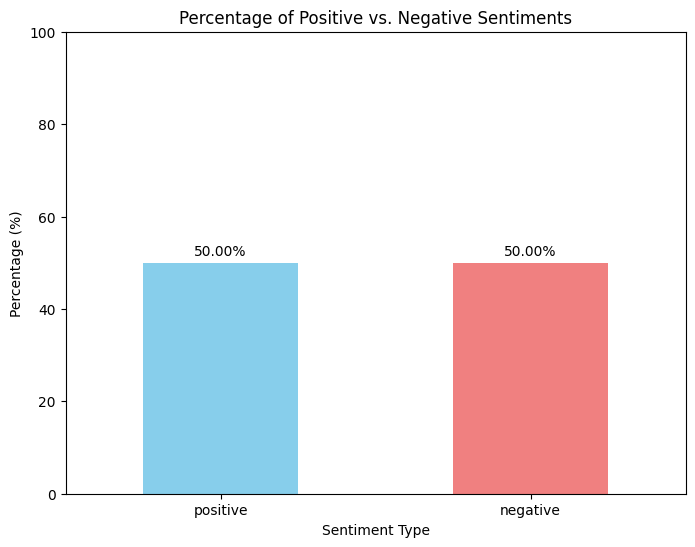

In [4]:
import matplotlib.pyplot as plt

# Calculate the percentage of each sentiment type
sentiment_counts = df['sentiment'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Percentage of Positive vs. Negative Sentiments')
plt.xlabel('Sentiment Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100) # Ensure y-axis goes from 0 to 100

# Add percentage labels on top of the bars
for index, value in enumerate(sentiment_counts):
    plt.text(index, value + 1, f'{value:.2f}%', ha='center', va='bottom')

plt.show()

In [5]:
# Display summary of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
# Check for null values in df
df.isnull().sum()

,0
review,0
sentiment,0


In [7]:
# Generate descriptive stats for numerical columns in df
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


### 2. Text Preprocessing

Remove stopwords, convert all text to lowercase, and remove special characters, empty spaces.

In [8]:
import nltk
nltk.download('wordnet')
import subprocess
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [9]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

STOPWORDS = set(stopwords.words('english'))
STOPWORDS.remove('not')
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower() # Lowercase text
    text = ' '.join(word for word in text.split() if word not in STOPWORDS) # Remove stopwords from text
    text = re.sub(r'\W', ' ', text) # Remove all the special characters
    text = re.sub(r'\d+', '', text) # Remove numerical values
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'http\S+', '', text) # Remove URLs
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)  # Remove all single characters
    text = re.sub(r'\^[a-zA-Z]\s+', ' ', text) # Remove single characters from the start
    text = re.sub(r'\s+', ' ', text, flags=re.I) # Substituting multiple spaces with single space
    text = ' '.join(lemmatizer.lemmatize(word) for word in text.split()) # Perform lemmatization
    return text

df['review'] = df['review'].apply(clean_text)
df.head()

,review,sentiment
0,one reviewer mentioned watching oz episode hoo...,positive
1,wonderful little production br br the filming ...,positive
2,thought wonderful way spend time hot summer we...,positive
3,basically there family little boy jake think t...,negative
4,petter mattei love time money visually stunnin...,positive


Tokenisation

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# The maximum number of words to be used. (most frequent)
MAX_Number_of_WORDS = 10000 #50000

# Max number of words in each review.
MAX_lenght_of_sequeunce = 250

# Fixing the dimension of the word embedding vector
Embedding_Dimention = 100

# Create a tokenizer object with specified parameters
tokenizer = Tokenizer(num_words=MAX_Number_of_WORDS, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)

# Fit the tokenizer on the text data
tokenizer.fit_on_texts(df['review'].values)

# Get the word-to-index mapping for the tokenizer
word_index = tokenizer.word_index

# Print the number of unique tokens in the vocabulary
print('Found %s unique tokens.' % len(word_index))

# Convert the text data to sequences of integers
X = tokenizer.texts_to_sequences(df['review'].values)

# Pad/truncate sequences to a fixed length
X = pad_sequences(X, maxlen=MAX_lenght_of_sequeunce)

# Print the shape of the data tensor
print('Shape of data tensor:', X.shape)

Found 90450 unique tokens.
Shape of data tensor: (50000, 250)


Create a Word Cloud to visualise the text data, where the size of each word indicates its frequency or importance within a text.

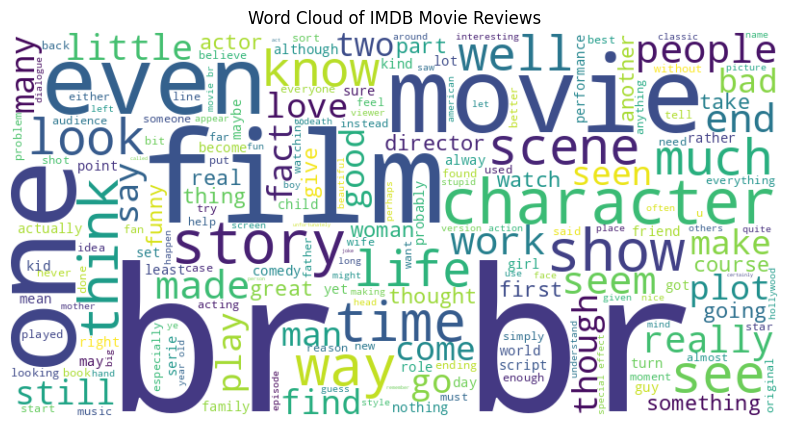

In [11]:
from wordcloud import WordCloud

# Join all the reviews into a single string
all_reviews = ' '.join(df['review'])

# Generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of IMDB Movie Reviews')
plt.show()

### 3. Train-Test Split

In [12]:
from sklearn.model_selection import train_test_split

# Map "positive" and "negative" to 1 and 0
Y= df['sentiment'].map({'positive': 1, 'negative': 0})

# Split the data into training and testing sets (80/20 split)
train_texts, rest_texts, train_labels, rest_labels = train_test_split(X, Y, train_size=0.8, random_state=42)

# Split the training data into training and validation sets (80/10/10 split)
test_texts, val_texts, test_labels, val_labels = train_test_split(rest_texts, rest_labels, test_size=0.5, random_state=42)

# Print the shape of each split
print("Shape of training texts: ", train_texts.shape)
print("Shape of training labels: ", train_labels.shape)
print("Shape of validation texts: ", val_texts.shape)
print("Shape of validation labels: ", val_labels.shape)
print("Shape of testing texts: ", test_texts.shape)
print("Shape of testing labels: ", test_labels.shape)

Shape of training texts:  (40000, 250)
Shape of training labels:  (40000,)
Shape of validation texts:  (5000, 250)
Shape of validation labels:  (5000,)
Shape of testing texts:  (5000, 250)
Shape of testing labels:  (5000,)


### 4. Model Building

We will be building a stacked LSTM to check the performance and also use dropout regularisation to get rid of overfitting.

Note: A stacked LSTM is a type of RNN consisting of multiple layers of LSTM cells - each layer in the stack processes the input sequence & produces an output that is passed as an input to the next layer in the stack. The final output is used to make a prediction or classification. (A stacked LSTM allows the model to learn more complex & abstract representations of the input sequence, leading to better performance on tasks that require modelling long-term dependencies & capturing subtle relationships b/w different parts of the input sequence.)

In [13]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, Bidirectional,  SpatialDropout1D
from keras.optimizers import Adam

# Define LSTM model with 2 stacked LSTM layers
model_sentiment = Sequential()

# Add an embedding layer to the model, which maps integer-encoded tokens to dense vectors
model_sentiment.add(Embedding(MAX_Number_of_WORDS, Embedding_Dimention, input_length=X.shape[1]))

# Add a dropout layer to randomly drop some of the input, which can help prevent overfitting
model_sentiment.add(SpatialDropout1D(0.3))

# Add the first LSTM layer, which has 64 units and returns the full sequence of outputs. The dropout rate is set to 0.3 for input and recurrent connections to prevent overfitting
model_sentiment.add(LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=True))

# Add the second LSTM layer, which has 32 units and returns only the final output
model_sentiment.add(LSTM(32, dropout=0.3, recurrent_dropout=0.3))

# Add a dense output layer with 2 units and a softmax activation function for binary classification
model_sentiment.add(Dense(1, activation='sigmoid'))

# Defining learning rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

# Compile the model with categorical cross-entropy loss, Adam optimizer, and accuracy metric
model_sentiment.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Explicitly build the model to show parameter counts in the summary
model_sentiment.build(input_shape=(None, X.shape[1]))

# Print a summary of the model architecture, including the number of parameters in each layer
print(model_sentiment.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 250, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 250, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,054,689 (4.02 MB)

 Trainable params: 1,054,689 (4.02 MB)

 Non-trainable params: 0 (0.00 B)

None


### 5. Model Training

To prevent overfitting, we will implement EarlyStopping.

This technique monitors the validation loss during training and stops the training process if the validation loss does not improve for a specified number of epochs, helping to find the optimal point before the model starts to overfit the training data.

In [14]:
from keras.callbacks import EarlyStopping

epochs=10
batch_size=32

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

history = model_sentiment.fit(train_texts, train_labels, epochs=epochs, batch_size=batch_size, validation_data=(val_texts, val_labels), callbacks=[early_stopping], verbose=2)

Epoch 1/10
1250/1250 - 309s - 247ms/step - accuracy: 0.8203 - loss: 0.4057 - val_accuracy: 0.8658 - val_loss: 0.3194
Epoch 2/10
1250/1250 - 308s - 246ms/step - accuracy: 0.8811 - loss: 0.2990 - val_accuracy: 0.8630 - val_loss: 0.3426
Epoch 3/10
1250/1250 - 306s - 245ms/step - accuracy: 0.9005 - loss: 0.2580 - val_accuracy: 0.8782 - val_loss: 0.2935
Epoch 4/10
1250/1250 - 307s - 245ms/step - accuracy: 0.9087 - loss: 0.2383 - val_accuracy: 0.8804 - val_loss: 0.2917
Epoch 5/10
1250/1250 - 302s - 242ms/step - accuracy: 0.9202 - loss: 0.2111 - val_accuracy: 0.8906 - val_loss: 0.2814
Epoch 6/10
1250/1250 - 327s - 261ms/step - accuracy: 0.9298 - loss: 0.1889 - val_accuracy: 0.8796 - val_loss: 0.2989
Epoch 7/10
1250/1250 - 303s - 242ms/step - accuracy: 0.9373 - loss: 0.1696 - val_accuracy: 0.8832 - val_loss: 0.3050
Epoch 8/10
1250/1250 - 320s - 256ms/step - accuracy: 0.9472 - loss: 0.1493 - val_accuracy: 0.8836 - val_loss: 0.3261


### 6. Model Evaluation on Test Data

In [15]:
loss, accuracy = model_sentiment.evaluate(test_texts, test_labels, verbose=2)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

157/157 - 8s - 50ms/step - accuracy: 0.8848 - loss: 0.2938
Test Loss: 0.2938
Test Accuracy: 0.8848


### 7. Visualise Training History

Plotting the training & validation accuracy and loss over the epochs can help us identify if the model overfits or underfits, and also provide insights into potential improvements.

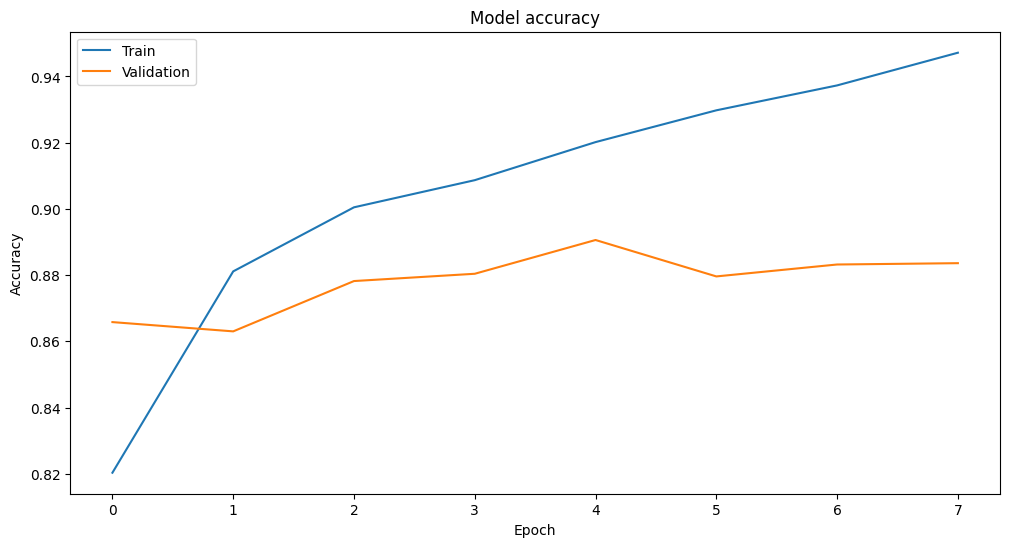

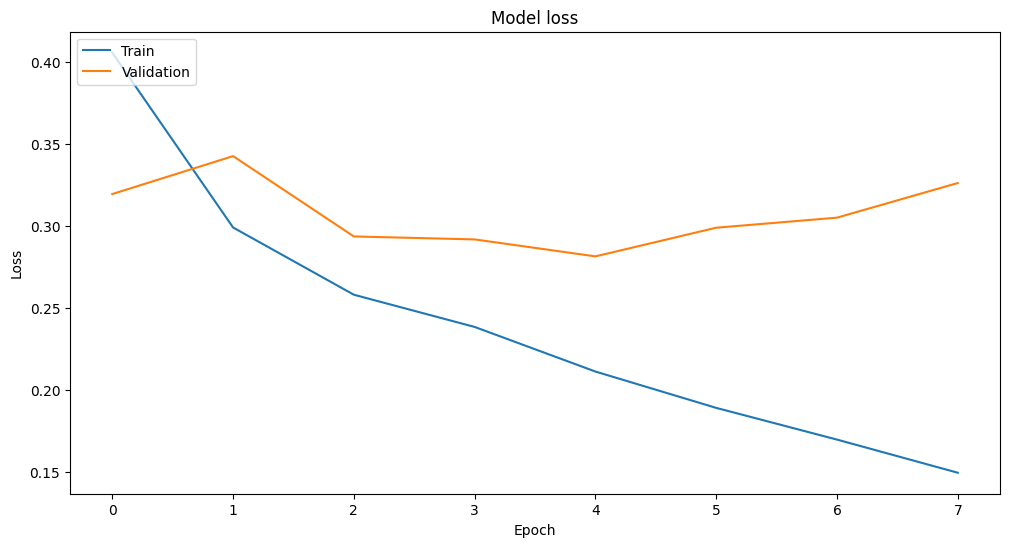

In [16]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### 8. Sentiment Prediction on New Data


Now, let's use our trained model to predict the sentiment of some new review texts. The `predict_sentiment` function will take a raw text review, clean it using the same preprocessing steps, tokenize and pad it, and then feed it to the model for a sentiment prediction.

In [17]:
def predict_sentiment(text):
    # Clean the input text using the same preprocessing function
    cleaned_text = clean_text(text)

    # Convert the text to a sequence of integers using the fitted tokenizer
    # The texts_to_sequences method expects a list of texts
    seq = tokenizer.texts_to_sequences([cleaned_text])

    # Pad the sequence to the maximum length used during training
    padded_seq = pad_sequences(seq, maxlen=MAX_lenght_of_sequeunce)

    # Make a prediction with the model
    prediction = model_sentiment.predict(padded_seq)[0][0]

    # Interpret the prediction
    if prediction >= 0.5:
        return 'Positive', prediction
    else:
        return 'Negative', prediction

# Example usage:
new_reviews = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "What a terrible waste of time. I regret watching this film.",
    "It was okay, not great, not bad. Just mediocre.",
    "The acting was phenomenal, but the plot was a bit weak. Overall, a decent watch."
]

for review in new_reviews:
    sentiment, confidence = predict_sentiment(review)
    print(f"Review: '{review}'\nPredicted Sentiment: {sentiment} (Confidence: {confidence:.2f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
Review: 'This movie was absolutely fantastic! I loved every minute of it.'
Predicted Sentiment: Positive (Confidence: 0.89)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Review: 'What a terrible waste of time. I regret watching this film.'
Predicted Sentiment: Negative (Confidence: 0.01)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Review: 'It was okay, not great, not bad. Just mediocre.'
Predicted Sentiment: Negative (Confidence: 0.02)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Review: 'The acting was phenomenal, but the plot was a bit weak. Overall, a decent watch.'
Predicted Sentiment: Negative (Confidence: 0.36)



### 9. Model Deployment

Save the trained Keras Sentiment Analysis Model & the associated tokenizer, and then create a Hugging Face Space with a Gradio application to provide an interactive interface for sentiment prediction using the deployed model.

In [20]:
import pickle

# Save the Keras model
model_sentiment.save('keras_model.keras')
print("Keras model saved as 'keras_model.keras'")

# Save the tokenizer object
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("Tokenizer saved as 'tokenizer.pickle'")

Keras model saved as 'keras_model.keras'
Tokenizer saved as 'tokenizer.pickle'


Create app.py codefile.

In [21]:
%%writefile app.py

import tensorflow as tf
from tensorflow import keras
import pickle
import nltk
import re
import gradio as gr
import numpy as np
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download necessary NLTK data
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# Initialize NLTK components
STOPWORDS = set(stopwords.words('english'))
STOPWORDS.remove('not')
lemmatizer = WordNetLemmatizer()

# Define the clean_text function exactly as in the notebook
def clean_text(text):
    text = text.lower() # Lowercase text
    text = ' '.join(word for word in text.split() if word not in STOPWORDS) # Remove stopwords from text
    text = re.sub(r'\W', ' ', text) # Remove all the special characters
    text = re.sub(r'\d+', '', text) # Remove numerical values
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = re.sub(r'http\S+', '', text) # Remove URLs
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)  # Remove all single characters
    text = re.sub(r'\^[a-zA-Z]\s+', ' ', text) # Remove single characters from the start
    text = re.sub(r'\s+', ' ', text, flags=re.I) # Substituting multiple spaces with single space
    text = ' '.join(lemmatizer.lemmatize(word) for word in text.split()) # Perform lemmatization
    return text

# Global constant for sequence length
MAX_lenght_of_sequeunce = 250

# Load the Keras model
model_sentiment = tf.keras.models.load_model('keras_model.keras')

# Load the tokenizer
with open('tokenizer.pickle', 'rb') as handle:
    tokenizer = pickle.load(handle)

def predict_sentiment(text):
    # Clean the input text
    cleaned_text = clean_text(text)

    # Convert the text to a sequence of integers
    seq = tokenizer.texts_to_sequences([cleaned_text])

    # Pad the sequence
    padded_seq = pad_sequences(seq, maxlen=MAX_lenght_of_sequeunce)

    # Make a prediction with the model
    prediction = model_sentiment.predict(padded_seq)[0][0]

    # Interpret the prediction
    if prediction >= 0.5:
        return 'Positive', float(prediction)
    else:
        return 'Negative', float(prediction)

# Create Gradio interface
interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Enter movie review here..."),
    outputs=["text", gr.Number(label="Confidence Score")],
    title="IMDB Movie Review Sentiment Analysis",
    description="Enter a movie review to classify its sentiment as Positive or Negative using a trained LSTM model.",
    live=True
)

# Launch the Gradio app
if __name__ == '__main__':
    interface.launch(share=True)

Writing app.py
